## Extracting Chess Squares with Perspective Transformation ( image --> fen format)

<br>
<font size="4">
Notebook version of perspective_transformation.py file. You can  understand better all the process by observing cell by cell.<br>  You can use this file for testing 
</font>
<br><br><br><br>

<br>

#### Necessary Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 
import  math
import csv
from reportlab.graphics import renderPM
from PIL import Image
import os

 

<br>

#### Display Image

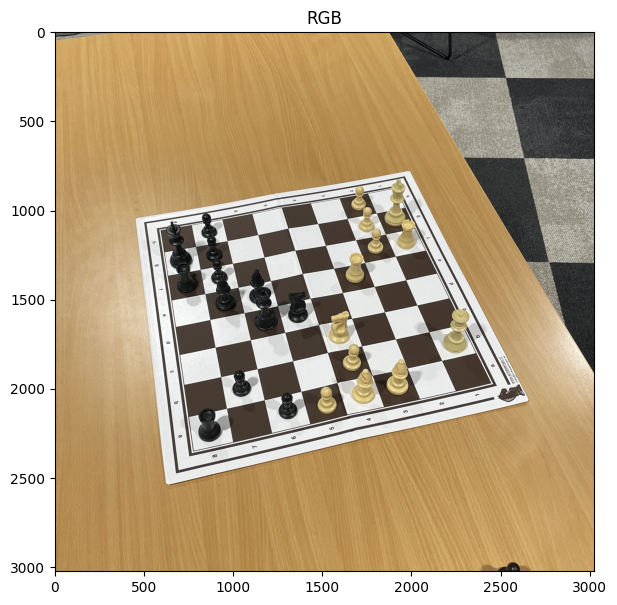

In [3]:
# Path of Image that you want to convert
image_path = r"images" # mudar path se for preciso
# read image and convert it to different color spaces 
image = cv2.imread(os.path.join((image_path),"G033_IMG043.jpg"))   #escolher a imagem
gray_image=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
rgb_image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
 
plt.figure(figsize=(9,7))
plt.imshow(rgb_image)
plt.title("RGB");

<br>


## Processing Image 
####  OTSU Threshold , Canny , dilate , HoughLinesP 

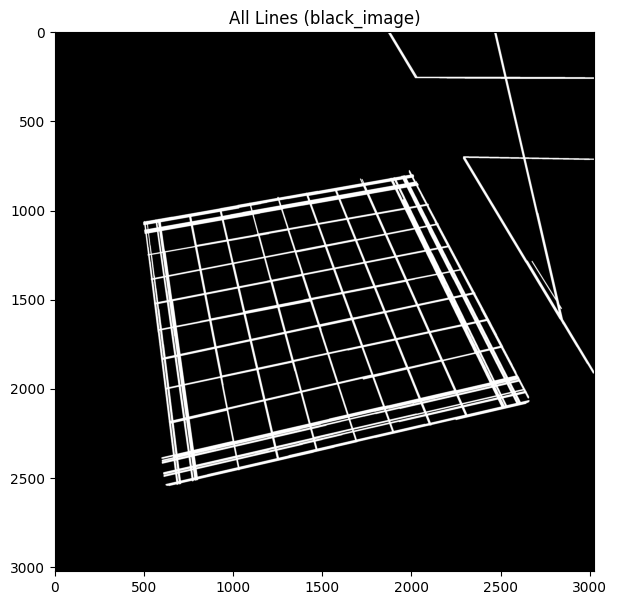

In [4]:
# OTSU threshold
ret, otsu_binary = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Canny edge detection
canny_image = cv2.Canny(otsu_binary, 20, 255)

# Dilation
kernel = np.ones((7, 7), np.uint8)
dilation_image = cv2.dilate(canny_image, kernel, iterations=1)

# Hough Lines
lines = cv2.HoughLinesP(dilation_image, 1, np.pi / 180, threshold=500, minLineLength=150, maxLineGap=100)


# Create an image that contains only black pixels
black_image = np.zeros_like(dilation_image)

# Draw only lines that are output of HoughLinesP function to the "black_image"
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # draw only lines to the "black_image"
        cv2.line(black_image, (x1, y1), (x2, y2), (255, 255, 255), 2)

# Dilation
kernel = np.ones((3, 3), np.uint8)
black_image = cv2.dilate(black_image, kernel, iterations=1)

plt.figure(figsize=(9,7))
plt.title("All Lines (black_image)")
plt.imshow(black_image,cmap="gray")


<br>


#### Find Contours , sort contours points(4 point), and display valid squares on new fully black image

#### By saying "valid squares" , I mean geometrically. With some threshold value , 4 length of a square must be close to each other 

#### 4 point --> bottomright , topright , topleft , bottomleft

Image dimensions: 3024x3024
Min square area: 9144.58, Max square area: 274337.28
Total contours found: 556
Found 64 valid squares


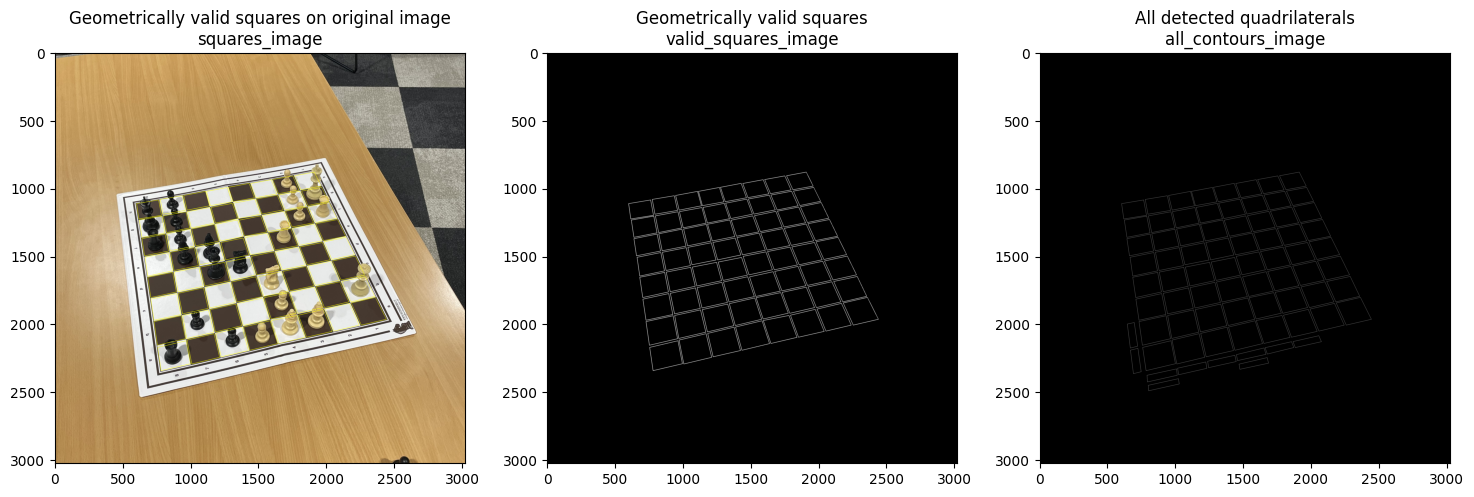

In [5]:
# Look for valid squares and check if squares are inside of board
import math  # Make sure to import math module

# Find contours
board_contours, hierarchy = cv2.findContours(black_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Blank image for displaying all contours
all_contours_image = np.zeros_like(black_image)

# Copy input image for displaying all squares 
squares_image = np.copy(image) 

# Blank image for displaying valid contours (squares)
valid_squares_image = np.zeros_like(black_image)

# Improved square filtering
valid_squares = []

# Calculate image size for reference
img_area = image.shape[0] * image.shape[1]

# Fine-tuned parameters specifically for chess squares
# Chess squares should be within a certain size range relative to the image
min_square_area = 0.001 * img_area  # Adjust based on your chess board size
max_square_area = 0.03 * img_area   # Adjust based on your chess board size

# For the edge case with smaller squares, you might need to adjust:
# min_square_area = 0.0005 * img_area
# max_square_area = 0.01 * img_area

# Print parameters for debugging
print(f"Image dimensions: {image.shape[1]}x{image.shape[0]}")
print(f"Min square area: {min_square_area:.2f}, Max square area: {max_square_area:.2f}")
print(f"Total contours found: {len(board_contours)}")

# Loop through contours and filter them by deciding if they are potential squares
for contour in board_contours:
    area = cv2.contourArea(contour)
    if min_square_area < area < max_square_area:
        # Approximate the contour to a simpler shape
        epsilon = 0.03 * cv2.arcLength(contour, True)  # Balanced epsilon value #mudei de 0.03
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        # If polygon has 4 vertices (a quadrilateral)
        if len(approx) == 4:
            # 4 points of polygon
            pts = [pt[0].tolist() for pt in approx]

            # Create same pattern for points
            # Sort by x-coordinate (reverse for right-to-left order)
            index_sorted = sorted(pts, key=lambda x: x[0], reverse=True)

            # Adjust Y values to properly identify corners
            if index_sorted[0][1] < index_sorted[1][1]:
                cur = index_sorted[0]
                index_sorted[0] = index_sorted[1]
                index_sorted[1] = cur

            if index_sorted[2][1] > index_sorted[3][1]:
                cur = index_sorted[2]
                index_sorted[2] = index_sorted[3]
                index_sorted[3] = cur

            # bottomright(1), topright(2), topleft(3), bottomleft(4)
            pt1 = index_sorted[0]
            pt2 = index_sorted[1]
            pt3 = index_sorted[2]
            pt4 = index_sorted[3]

            # Calculate length of 4 sides of rectangle
            l1 = math.sqrt((pt1[0] - pt2[0])**2 + (pt1[1] - pt2[1])**2)
            l2 = math.sqrt((pt2[0] - pt3[0])**2 + (pt2[1] - pt3[1])**2)
            l3 = math.sqrt((pt3[0] - pt4[0])**2 + (pt3[1] - pt4[1])**2)
            l4 = math.sqrt((pt1[0] - pt4[0])**2 + (pt1[1] - pt4[1])**2)
 
            # Create a list of lengths
            lengths = [l1, l2, l3, l4]
            
            # Get the maximum and minimum lengths
            max_length = max(lengths)
            min_length = min(lengths)

            # Calculate the aspect ratio of the rectangle
            aspect_ratio = max_length / min_length if min_length > 0 else float('inf')
            
            # Calculate diagonals
            d1 = math.sqrt((pt1[0] - pt3[0])**2 + (pt1[1] - pt3[1])**2)
            d2 = math.sqrt((pt2[0] - pt4[0])**2 + (pt2[1] - pt4[1])**2)
            
            # Calculate diagonal ratio
            diagonal_ratio = max(d1, d2) / min(d1, d2) if min(d1, d2) > 0 else float('inf')
            
            # Chess squares should be square-ish, with reasonable ratios
            # Fine-tuned thresholds for chess squares
            is_square = (
                aspect_ratio < 2 and       # Sides should be similar (square-like) #mudei para 1
                diagonal_ratio < 2 and     # Diagonals should be similar
                (max_length - min_length) < 230  # Max difference between sides
            )
            
            if is_square:
                valid_square = True
                valid_squares.append(approx)
            else:
                valid_square = False
 
            # Draw all quadrilaterals to "all_contours_image"
            # Use integer coordinates to avoid drawing errors
            pt1_int = (int(pt1[0]), int(pt1[1]))
            pt2_int = (int(pt2[0]), int(pt2[1]))
            pt3_int = (int(pt3[0]), int(pt3[1]))
            pt4_int = (int(pt4[0]), int(pt4[1]))
            
            cv2.line(all_contours_image, pt1_int, pt2_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt2_int, pt3_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt3_int, pt4_int, (255, 255, 255), 1)
            cv2.line(all_contours_image, pt1_int, pt4_int, (255, 255, 255), 1)
 
            if valid_square:
                # Draw the lines between the points for valid squares
                cv2.line(squares_image, pt1_int, pt2_int, (0, 255, 255), 2)  # Yellow
                cv2.line(squares_image, pt2_int, pt3_int, (0, 255, 255), 2)
                cv2.line(squares_image, pt3_int, pt4_int, (0, 255, 255), 2)
                cv2.line(squares_image, pt1_int, pt4_int, (0, 255, 255), 2)

                # Draw only valid squares to "valid_squares_image"
                cv2.line(valid_squares_image, pt1_int, pt2_int, (255, 255, 255), 2)
                cv2.line(valid_squares_image, pt2_int, pt3_int, (255, 255, 255), 2)
                cv2.line(valid_squares_image, pt3_int, pt4_int, (255, 255, 255), 2)
                cv2.line(valid_squares_image, pt1_int, pt4_int, (255, 255, 255), 2)

print(f"Found {len(valid_squares)} valid squares")

# Display results
plt.figure(figsize=(18, 15))

plt.subplot(131)
plt.title("Geometrically valid squares on original image\nsquares_image")
plt.imshow(cv2.cvtColor(squares_image, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.title("Geometrically valid squares\nvalid_squares_image")
plt.imshow(valid_squares_image, cmap="gray")

plt.subplot(133)
plt.title("All detected quadrilaterals\nall_contours_image")
plt.imshow(all_contours_image, cmap="gray")
plt.show()

<br>


#### Dilation to the image that contains only valid squares (gemoetrically valid)

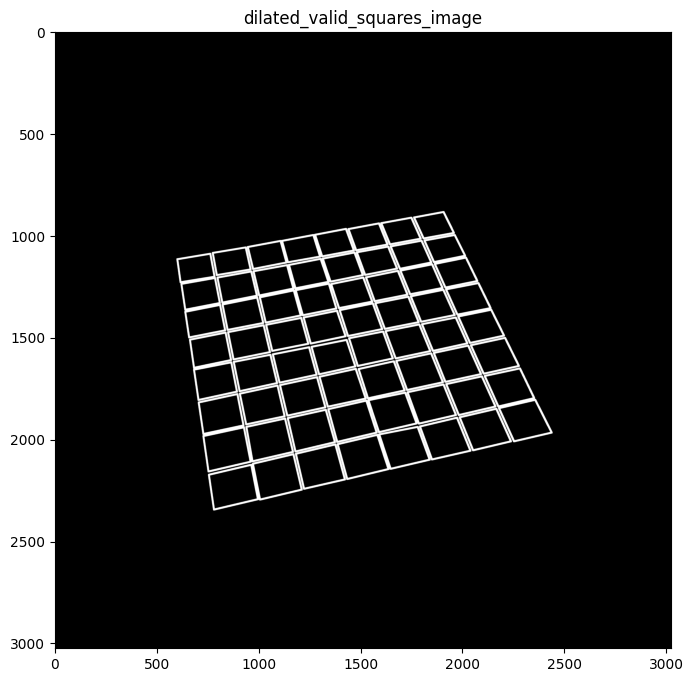

In [6]:
# Apply dilation to the valid_squares_image
kernel = np.ones((7, 7), np.uint8)
dilated_valid_squares_image = cv2.dilate(valid_squares_image, kernel, iterations=1)

plt.figure(figsize=(12,8))
plt.title("dilated_valid_squares_image")
plt.imshow(dilated_valid_squares_image,cmap="gray")

# FROM HERE ON OUT IT IS THE CODE FROM THE FOUND REPOSITORY, CLAUDE, SO THIS IS WHERE MY WORK STOPS


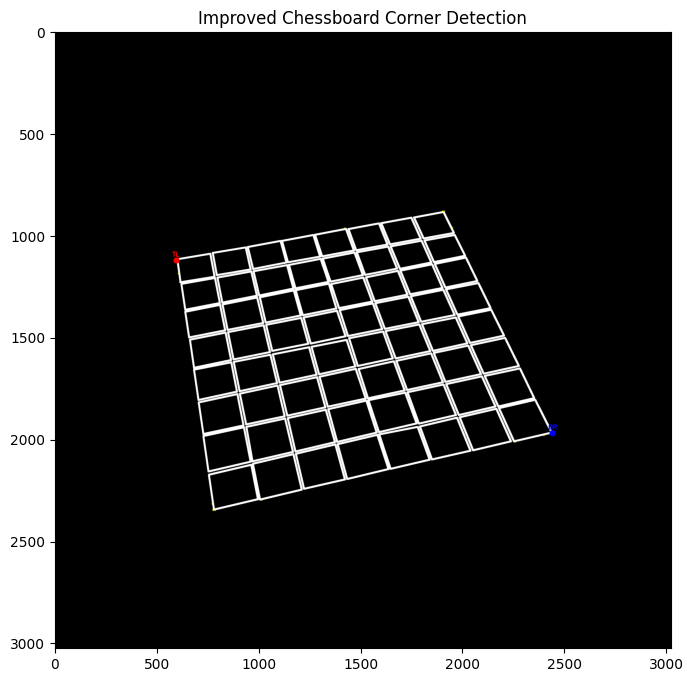

Top-left corner: (np.int32(596), np.int32(1121))
Top-right corner: None
Bottom-left corner: None
Bottom-right corner: (np.int32(2442), np.int32(1969))


In [7]:
# A better approach for corner detection
# Since we already have a good grid of squares, we can find the extremes
# Find all white pixels in the image
white_pixels = np.where(dilated_valid_squares_image > 0)
points = np.column_stack((white_pixels[1], white_pixels[0]))  # x, y format

if len(points) > 0:
    # Find the convex hull of all white pixels
    hull = cv2.convexHull(points)
    
    # Find the extreme points from the hull
    leftmost = tuple(hull[hull[:, :, 0].argmin()][0])
    rightmost = tuple(hull[hull[:, :, 0].argmax()][0])
    topmost = tuple(hull[hull[:, :, 1].argmin()][0])
    bottommost = tuple(hull[hull[:, :, 1].argmax()][0])
    
    # Find the four corners by examining all hull points
    corners = []
    for point in hull:
        point = tuple(point[0])
        corners.append(point)
    
    # Sort corners by distance from center
    center_x = np.mean([p[0] for p in corners])
    center_y = np.mean([p[1] for p in corners])
    
    # Calculate distance from each corner to center
    corner_distances = []
    for corner in corners:
        dist = np.sqrt((corner[0] - center_x)**2 + (corner[1] - center_y)**2)
        angle = np.arctan2(corner[1] - center_y, corner[0] - center_x)
        corner_distances.append((corner, dist, angle))
    
    # Sort by distance (largest first)
    corner_distances.sort(key=lambda x: x[1], reverse=True)
    
    # Take the top 10 farthest points
    far_corners = corner_distances[:10]
    
    # Find corners in each quadrant
    top_left = None
    top_right = None
    bottom_left = None
    bottom_right = None
    
    # For each potential corner, determine which quadrant it's in
    for corner, dist, angle in far_corners:
        x, y = corner
        
        # Top-left quadrant
        if x < center_x and y < center_y:
            if top_left is None or dist > corner_distances[corners.index(top_left)][1]:
                top_left = corner
        
        # Top-right quadrant
        elif x >= center_x and y < center_y:
            if top_right is None or dist > corner_distances[corners.index(top_right)][1]:
                top_right = corner
        
        # Bottom-left quadrant
        elif x < center_x and y >= center_y:
            if bottom_left is None or dist > corner_distances[corners.index(bottom_left)][1]:
                bottom_left = corner
        
        # Bottom-right quadrant
        else:  # x >= center_x and y >= center_y
            if bottom_right is None or dist > corner_distances[corners.index(bottom_right)][1]:
                bottom_right = corner
    
    # Create an RGB image for visualization
    corner_img = cv2.cvtColor(dilated_valid_squares_image, cv2.COLOR_GRAY2BGR)
    
    # Draw all hull points
    for point in hull:
        cv2.circle(corner_img, tuple(point[0]), 3, (0, 255, 255), -1)
    
    # Draw the corners if found
    if top_left:
        cv2.circle(corner_img, top_left, 15, (0, 0, 255), -1)  # Red
        cv2.putText(corner_img, "TL", (top_left[0] - 20, top_left[1] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
    
    if top_right:
        cv2.circle(corner_img, top_right, 15, (0, 255, 0), -1)  # Green
        cv2.putText(corner_img, "TR", (top_right[0] - 20, top_right[1] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
    
    if bottom_right:
        cv2.circle(corner_img, bottom_right, 15, (255, 0, 0), -1)  # Blue
        cv2.putText(corner_img, "BR", (bottom_right[0] - 20, bottom_right[1] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)
    
    if bottom_left:
        cv2.circle(corner_img, bottom_left, 15, (255, 255, 0), -1)  # Yellow
        cv2.putText(corner_img, "BL", (bottom_left[0] - 20, bottom_left[1] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 3)
    
    # Draw the quadrilateral if all corners found
    if all([top_left, top_right, bottom_right, bottom_left]):
        corners_array = np.array([top_left, top_right, bottom_right, bottom_left])
        cv2.polylines(corner_img, [corners_array.reshape(-1, 1, 2)], True, (0, 255, 255), 3)
    
    # Display the results
    plt.figure(figsize=(12, 8))
    plt.title("Improved Chessboard Corner Detection")
    plt.imshow(cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Print the corner coordinates
    print(f"Top-left corner: {top_left}")
    print(f"Top-right corner: {top_right}")
    print(f"Bottom-left corner: {bottom_left}")
    print(f"Bottom-right corner: {bottom_right}")
else:
    print("No white pixels found in the image")

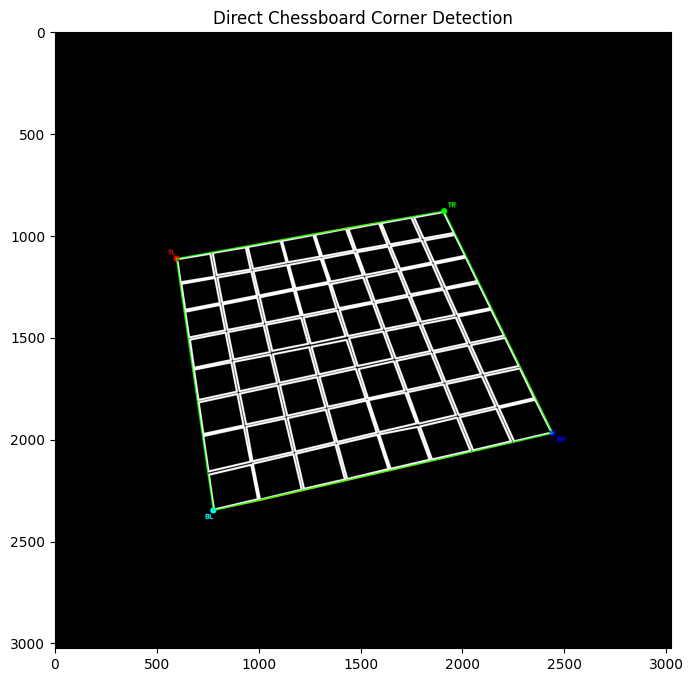

Top-left corner: (596, 1112)
Top-right corner: (1910, 879)
Bottom-left corner: (777, 2348)
Bottom-right corner: (2442, 1969)


In [8]:
# Let's take a simpler, more direct approach to find the four corners

# We already have the chessboard grid detected, we just need the four corners
# Start with a fresh approach based on the visible grid pattern

# First, find all the white pixels (grid lines) in the image
white_pixels = np.where(dilated_valid_squares_image > 0)
y_coords, x_coords = white_pixels

# Create a 2D array of coordinates
points = np.column_stack((x_coords, y_coords))

# Let's use a simple transformation based on the most extreme points
# Since the grid is a parallelogram, this should be more reliable than trying to find
# corners from hull or contours

# Get the convex hull of all points
if len(points) > 0:
    hull = cv2.convexHull(points.astype(np.float32))
    hull_points = [tuple(point[0]) for point in hull]
    
    # STRAIGHTFORWARD APPROACH: Find the four most extreme points
    # These will be our corners
    
    # Sort all hull points by x+y (smallest is top-left, largest is bottom-right)
    top_left = min(hull_points, key=lambda p: p[0] + p[1])
    bottom_right = max(hull_points, key=lambda p: p[0] + p[1])
    
    # Sort by x-y (largest is top-right, smallest is bottom-left)
    diff_values = [(p[0] - p[1], p) for p in hull_points]
    top_right = max(diff_values, key=lambda v: v[0])[1]
    bottom_left = min(diff_values, key=lambda v: v[0])[1]
    
    # Create an RGB image for visualization
    visual_img = cv2.cvtColor(dilated_valid_squares_image.copy(), cv2.COLOR_GRAY2BGR)
    
    # Draw the hull
    hull_array = np.array(hull_points).reshape(-1, 1, 2).astype(np.int32)
    cv2.polylines(visual_img, [hull_array], True, (0, 255, 255), 2)
    
    # Draw all hull points for verification
    for point in hull_points:
        x, y = int(point[0]), int(point[1])
        cv2.circle(visual_img, (x, y), 3, (100, 100, 255), -1)
    
    # Draw the detected corners with distinctive colors and labels
    cv2.circle(visual_img, (int(top_left[0]), int(top_left[1])), 15, (0, 0, 255), -1)  # Red for TL
    cv2.putText(visual_img, "TL", (int(top_left[0]) - 40, int(top_left[1]) - 20), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
    
    cv2.circle(visual_img, (int(top_right[0]), int(top_right[1])), 15, (0, 255, 0), -1)  # Green for TR
    cv2.putText(visual_img, "TR", (int(top_right[0]) + 20, int(top_right[1]) - 20), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
    
    cv2.circle(visual_img, (int(bottom_left[0]), int(bottom_left[1])), 15, (255, 255, 0), -1)  # Yellow for BL
    cv2.putText(visual_img, "BL", (int(bottom_left[0]) - 40, int(bottom_left[1]) + 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 3)
    
    cv2.circle(visual_img, (int(bottom_right[0]), int(bottom_right[1])), 15, (255, 0, 0), -1)  # Blue for BR
    cv2.putText(visual_img, "BR", (int(bottom_right[0]) + 20, int(bottom_right[1]) + 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 3)
    
    # Draw the quadrilateral connecting the four corners
    corners_array = np.array([
        [int(top_left[0]), int(top_left[1])],
        [int(top_right[0]), int(top_right[1])],
        [int(bottom_right[0]), int(bottom_right[1])],
        [int(bottom_left[0]), int(bottom_left[1])]
    ]).reshape(-1, 1, 2)
    
    cv2.polylines(visual_img, [corners_array], True, (0, 255, 0), 3)
    
    # Display the results
    plt.figure(figsize=(12, 8))
    plt.title("Direct Chessboard Corner Detection")
    plt.imshow(cv2.cvtColor(visual_img, cv2.COLOR_BGR2RGB))
    plt.show()
    
    # Convert any numpy types to basic Python types for clean output
    def format_point(p):
        return (int(p[0]), int(p[1]))
    
    # Print the corner coordinates
    print(f"Top-left corner: {format_point(top_left)}")
    print(f"Top-right corner: {format_point(top_right)}")
    print(f"Bottom-left corner: {format_point(bottom_left)}")
    print(f"Bottom-right corner: {format_point(bottom_right)}")
else:
    print("No points found to form a convex hull.")

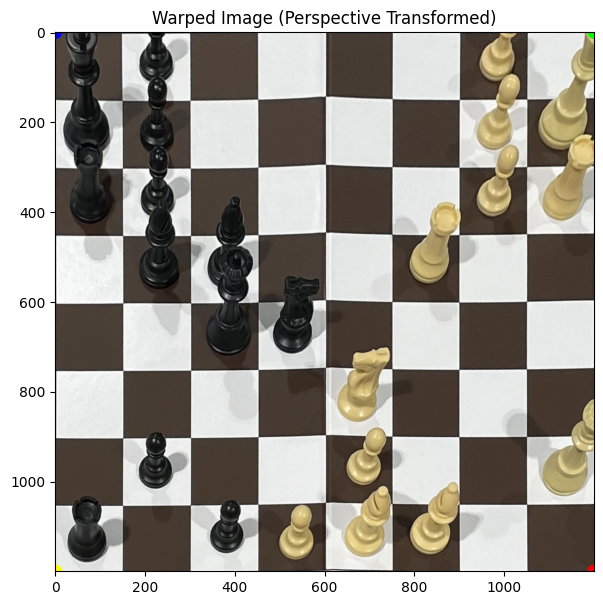

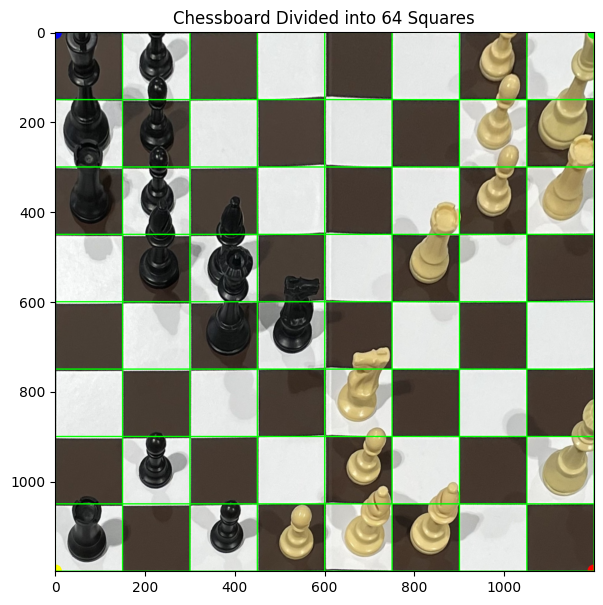

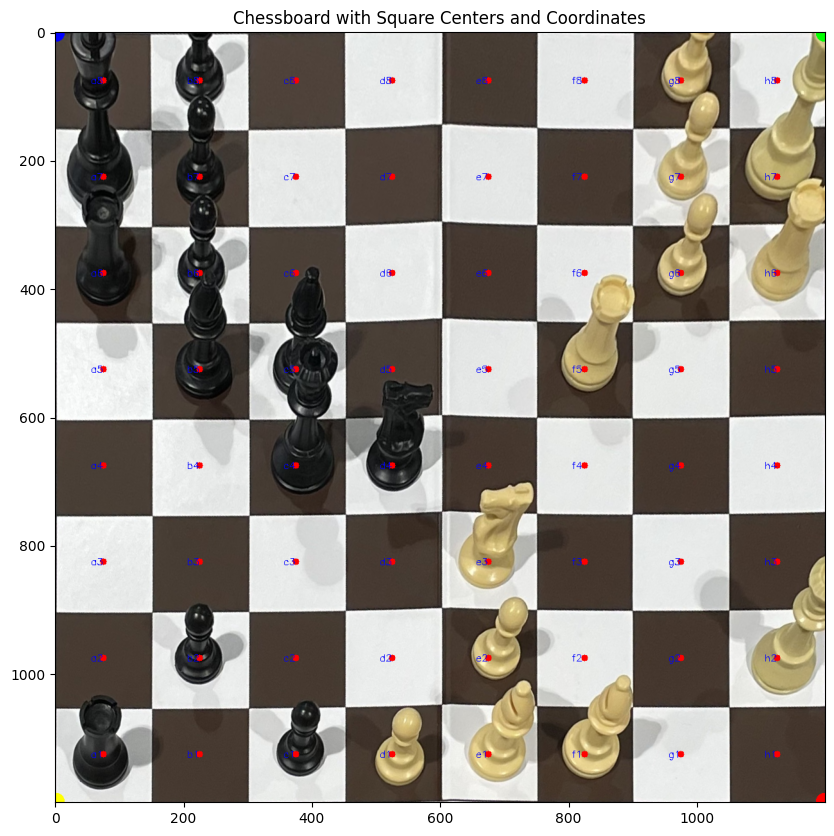

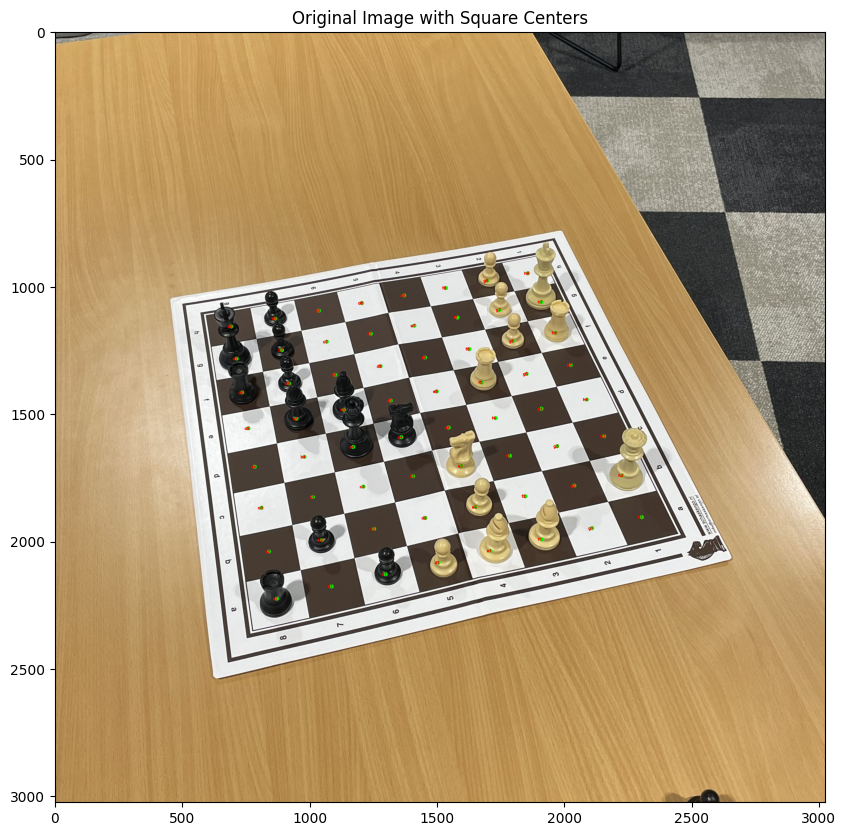

First few squares with their coordinates:
Square a1: Center at (871, 2225)
Square b1: Center at (1086, 2177)
Square c1: Center at (1298, 2129)
Square d1: Center at (1506, 2083)
Square e1: Center at (1710, 2037)


In [9]:
# Apply Perspective Transformation

# Read the original image
# If you're running this as a continuation of the corner detection, 
# make sure to reload the original image
# image = cv2.imread(image_path)
# rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Define the four source points (use the corners we detected)
# Make sure these are ordered correctly: [top_left, top_right, bottom_left, bottom_right]
extreme_points_list = np.float32([
    [top_left[0], top_left[1]],
    [top_right[0], top_right[1]],
    [bottom_left[0], bottom_left[1]],
    [bottom_right[0], bottom_right[1]]
])

# Set the output image dimensions
threshold = 0  # Extra space on all sides
width, height = 1200, 1200

# Define the destination points (shifted by 'threshold' on all sides)
dst_pts = np.float32([
    [threshold, threshold],  # Top-left
    [width + threshold, threshold],  # Top-right
    [threshold, height + threshold],  # Bottom-left
    [width + threshold, height + threshold]  # Bottom-right
])

# Compute the perspective transform matrix
M = cv2.getPerspectiveTransform(extreme_points_list, dst_pts)

# Apply the transformation with extra width and height
warped_image = cv2.warpPerspective(rgb_image, M, (width + 2 * threshold, height + 2 * threshold))

# Mark the corners in the warped image for verification
cv2.circle(warped_image, (threshold, threshold), 15, (0, 0, 255), -1)  # Top-left
cv2.circle(warped_image, (width + threshold, threshold), 15, (0, 255, 0), -1)  # Top-right
cv2.circle(warped_image, (threshold, height + threshold), 15, (255, 255, 0), -1)  # Bottom-left
cv2.circle(warped_image, (width + threshold, height + threshold), 15, (255, 0, 0), -1)  # Bottom-right

# Display the result
plt.figure(figsize=(9, 7))
plt.imshow(warped_image)
plt.title("Warped Image (Perspective Transformed)")
plt.show()

# Next, divide the board into 64 squares
rows, cols = 8, 8
square_width = width // cols
square_height = height // rows

# Create a copy to draw the grid lines
grid_image = warped_image.copy()

# Draw grid lines to divide the board into 64 squares
for i in range(rows + 1):
    y = i * square_height
    cv2.line(grid_image, (0, y), (width, y), (0, 255, 0), 2)

for j in range(cols + 1):
    x = j * square_width
    cv2.line(grid_image, (x, 0), (x, height), (0, 255, 0), 2)

# Display the result with grid
plt.figure(figsize=(9, 7))
plt.imshow(grid_image)
plt.title("Chessboard Divided into 64 Squares")
plt.show()

# Create a list to store all 64 squares with their coordinates
squares_data = []

# Extract each square's coordinates in the warped image
# Go from bottom to top (rank 1 to 8) and left to right (file a to h)
for i in range(rows - 1, -1, -1):  # Start from bottom row (rank 1)
    for j in range(cols):  # Left to right (file a to h)
        # Define the 4 corners of each square
        top_left_square = (j * square_width, i * square_height)
        top_right_square = ((j + 1) * square_width, i * square_height)
        bottom_left_square = (j * square_width, (i + 1) * square_height)
        bottom_right_square = ((j + 1) * square_width, (i + 1) * square_height)
        
        # Calculate center of the square
        center_x = (top_left_square[0] + bottom_right_square[0]) // 2
        center_y = (top_left_square[1] + bottom_right_square[1]) // 2
        
        # Append to the list
        squares_data.append({
            "center": (center_x, center_y),
            "corners": [bottom_right_square, top_right_square, top_left_square, bottom_left_square],
            "rank": 8 - i,  # Chess rank (1-8)
            "file": chr(97 + j)  # Chess file (a-h)
        })

# For visualization, create a copy of the warped image
square_centers_image = warped_image.copy()

# Draw square centers and labels
for square in squares_data:
    center = square["center"]
    rank = square["rank"]
    file = square["file"]
    
    # Draw center point
    cv2.circle(square_centers_image, center, 5, (255, 0, 0), -1)
    
    # Add coordinate label
    label = f"{file}{rank}"
    cv2.putText(square_centers_image, label, (center[0] - 20, center[1] + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

# Display the result with square centers and labels
plt.figure(figsize=(12, 10))
plt.imshow(square_centers_image)
plt.title("Chessboard with Square Centers and Coordinates")
plt.show()

# Now we need to map these warped coordinates back to the original image
# Convert square centers to numpy array for transformation
square_centers_warped = np.array([square["center"] for square in squares_data], dtype=np.float32).reshape(-1, 1, 2)

# Compute the inverse perspective transformation matrix
M_inv = cv2.invert(M)[1]

# Transform centers back to original image coordinates
square_centers_original = cv2.perspectiveTransform(square_centers_warped, M_inv)

# Update the squares_data with original image coordinates
for i, square in enumerate(squares_data):
    square["original_center"] = (
        int(square_centers_original[i][0][0]),
        int(square_centers_original[i][0][1])
    )

# Visualize the square centers on the original image
original_with_centers = rgb_image.copy()

for square in squares_data:
    center = square["original_center"]
    rank = square["rank"]
    file = square["file"]
    
    # Draw center point
    cv2.circle(original_with_centers, center, 8, (0, 255, 0), -1)
    
    # Add coordinate label
    label = f"{file}{rank}"
    cv2.putText(original_with_centers, label, (center[0] - 15, center[1] + 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Display the result
plt.figure(figsize=(12, 10))
plt.imshow(original_with_centers)
plt.title("Original Image with Square Centers")
plt.show()

# Print the first few square coordinates for verification
print("First few squares with their coordinates:")
for i in range(5):
    sq = squares_data[i]
    print(f"Square {sq['file']}{sq['rank']}: Center at {sq['original_center']}")

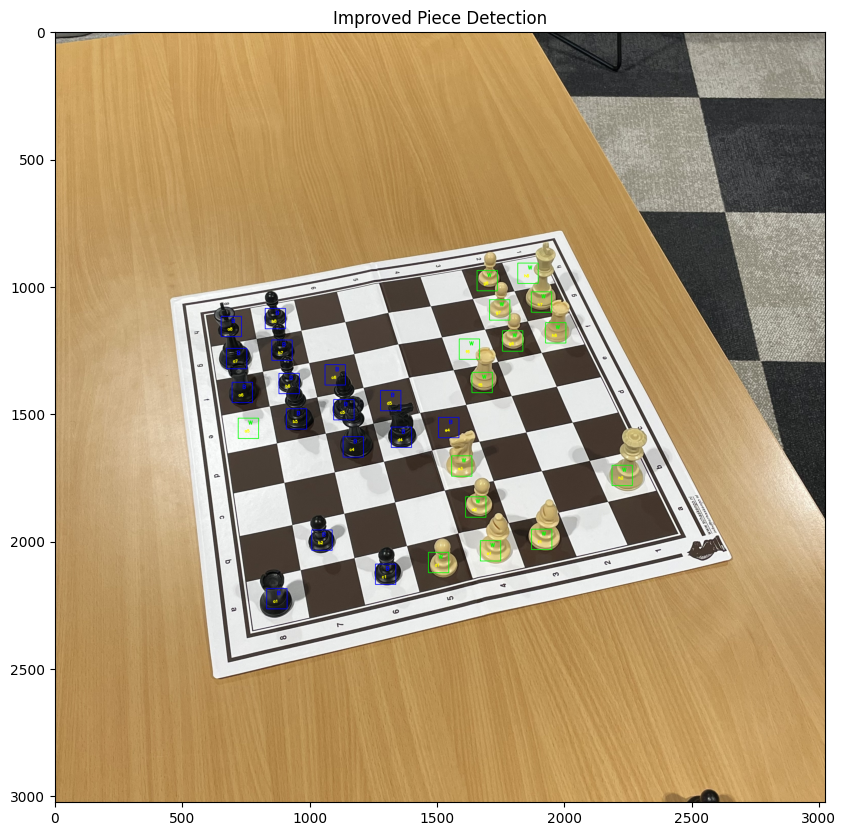

Total pieces detected: 31
White pieces: 15
Black pieces: 16

Board Matrix (1 for piece, 0 for empty):
[1, 1, 0, 0, 0, 0, 1, 1]
[1, 1, 0, 0, 0, 0, 1, 1]
[1, 1, 1, 0, 0, 1, 1, 1]
[1, 1, 1, 1, 0, 1, 0, 0]
[0, 0, 1, 1, 1, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 1, 0, 0, 1]
[1, 0, 1, 1, 1, 1, 0, 0]


In [10]:
# Improved Chess Piece Detection
# Instead of using color segmentation, let's use a more robust approach
# We'll analyze each square individually to detect pieces

def detect_pieces_in_squares(image, squares_data):
    """
    Detect chess pieces by analyzing each square individually
    
    Args:
        image: Original RGB image
        squares_data: List containing square information
    
    Returns:
        Detection results
    """
    # Convert to grayscale for easier processing
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Create a visualization image
    visualization = image.copy()
    
    # Keep track of pieces
    white_pieces = []
    black_pieces = []
    
    # Create a matrix to represent the board (0 for empty, 1 for occupied)
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    # Define a function to transform coordinates from warped space to original space
    def transform_to_original(warped_coords, M_inv):
        coords = np.array([warped_coords], dtype=np.float32).reshape(-1, 1, 2)
        transformed = cv2.perspectiveTransform(coords, M_inv)
        return (int(transformed[0][0][0]), int(transformed[0][0][1]))
    
    # For each square, extract features and determine if a piece is present
    for square_idx, square in enumerate(squares_data):
        # Get the original center of the square
        center = square["original_center"]
        rank = square["rank"]
        file = square["file"]
        
        # Define a region of interest (ROI) around the center
        roi_size = 50  # Adjust as needed
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI
        roi = gray_image[y1:y2, x1:x2]
        
        if roi.size == 0:
            continue  # Skip if ROI is outside image bounds
        
        # Analyze the ROI for features that indicate a piece
        # 1. Variance (pieces typically have higher variance due to shadows and shapes)
        variance = np.var(roi)
        
        # 2. Histogram features
        hist = cv2.calcHist([roi], [0], None, [32], [0, 256])
        hist_norm = hist / hist.sum()
        hist_entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-7))
        
        # 3. Gradients (pieces typically have stronger gradients)
        sobelx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # Set thresholds for piece detection
        has_piece = variance > 1000 and avg_gradient > 15
        
        # Determine piece color based on pixel intensity
        # Calculate the mean intensity of the ROI
        mean_intensity = np.mean(roi)
        
        # Threshold to distinguish between white and black pieces
        piece_color = "white" if mean_intensity > 127 else "black"
        
        # Create a bounding box around the piece
        bbox = (x1, y1, x2 - x1, y2 - y1)
        
        # File index (0-7) and rank index (0-7)
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            cv2.rectangle(visualization, (x1, y1), (x2, y2), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix (1 indicates piece present)
            # Convert from chess notation (a1 is bottom-left) to matrix indices (0,0 is top-left)
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "features": {
                    "variance": variance,
                    "hist_entropy": hist_entropy,
                    "avg_gradient": avg_gradient,
                    "mean_intensity": mean_intensity
                }
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Improve the detection by fine-tuning the parameters
# We need to adjust the thresholds to better match the image

# Let's add an adaptive approach that examines the distribution of features
def adaptive_piece_detection(image, squares_data):
    """
    Adaptively detect chess pieces by analyzing the distribution of features across squares
    """
    # Create a copy of the image
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    visualization = image.copy()
    
    # Extract features for all squares
    all_square_features = []
    
    for square in squares_data:
        center = square["original_center"]
        roi_size = 40  # Slightly smaller ROI
        
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI
        roi = gray_image[y1:y2, x1:x2]
        
        if roi.size == 0:
            # Skip empty ROIs
            all_square_features.append({
                "square": square,
                "variance": 0,
                "gradient": 0,
                "mean_intensity": 0,
                "bbox": (x1, y1, x2-x1, y2-y1)
            })
            continue
        
        # Calculate features
        variance = np.var(roi)
        
        # Gradient features
        sobelx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # Mean intensity
        mean_intensity = np.mean(roi)
        
        # Store features
        all_square_features.append({
            "square": square,
            "variance": variance,
            "gradient": avg_gradient,
            "mean_intensity": mean_intensity,
            "bbox": (x1, y1, x2-x1, y2-y1)
        })
    
    # Calculate feature distributions
    variances = [f["variance"] for f in all_square_features]
    gradients = [f["gradient"] for f in all_square_features]
    
    # Sort features
    sorted_variances = sorted(variances)
    sorted_gradients = sorted(gradients)
    
    # Adaptively find thresholds using a percentile approach
    # Aim to detect approximately half the squares as containing pieces
    
    # Get variance threshold at 50th percentile (median)
    if len(sorted_variances) > 0:
        variance_threshold = sorted_variances[len(sorted_variances) // 2]
    else:
        variance_threshold = 1000  # Fallback
    
    # Get gradient threshold at 50th percentile
    if len(sorted_gradients) > 0:
        gradient_threshold = sorted_gradients[len(sorted_gradients) // 2]
    else:
        gradient_threshold = 15  # Fallback
    
    # Apply thresholds to detect pieces
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    for features in all_square_features:
        square = features["square"]
        variance = features["variance"]
        gradient = features["gradient"]
        mean_intensity = features["mean_intensity"]
        bbox = features["bbox"]
        
        # Determine if this square contains a piece
        has_piece = variance > variance_threshold and gradient > gradient_threshold
        
        # Set color based on intensity
        piece_color = "white" if mean_intensity > 127 else "black"
        
        # Get chess coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        center = square["original_center"]
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            x1, y1, w, h = bbox
            cv2.rectangle(visualization, (x1, y1), (x1+w, y1+h), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "features": {
                    "variance": variance,
                    "gradient": gradient,
                    "mean_intensity": mean_intensity
                }
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix
    }
    
    return result, visualization

# Run the improved detection
adaptive_detection_result, adaptive_visualization = adaptive_piece_detection(rgb_image, squares_data)

# Display the improved detection
plt.figure(figsize=(12, 10))
plt.imshow(adaptive_visualization)
plt.title("Improved Piece Detection")
plt.show()

# Print statistics
print(f"Total pieces detected: {adaptive_detection_result['total_pieces_count']}")
print(f"White pieces: {adaptive_detection_result['white_pieces_count']}")
print(f"Black pieces: {adaptive_detection_result['black_pieces_count']}")

# Display the board matrix
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in adaptive_detection_result['board_matrix']:
    print(row)

Piece detection threshold: 26.21252924444431


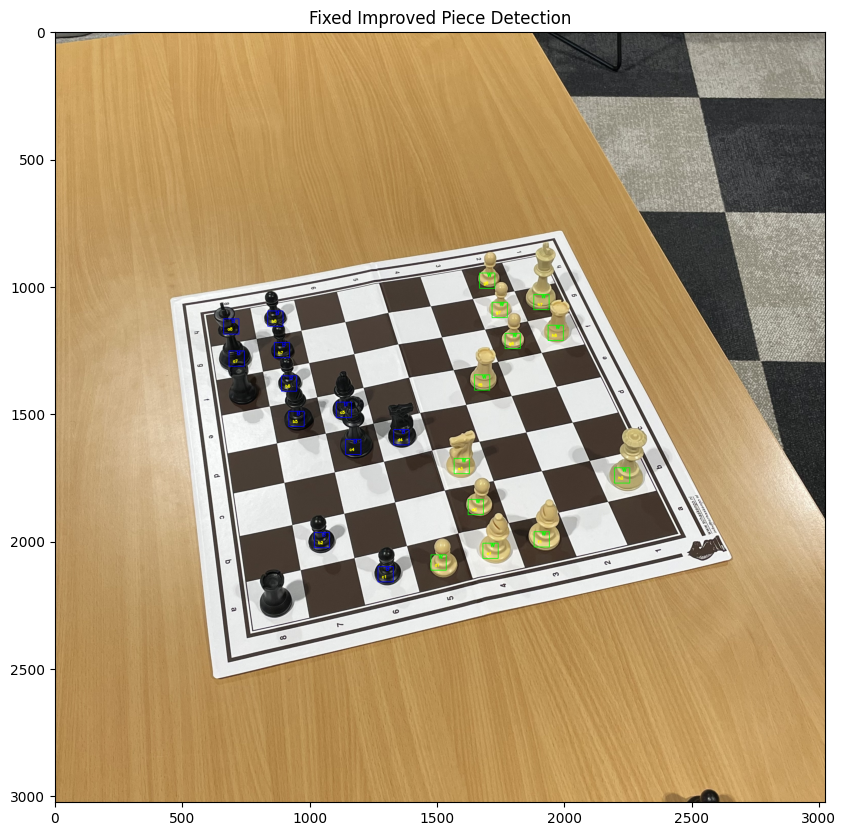

Total pieces detected: 23
White pieces: 12
Black pieces: 11

Board Matrix (1 for piece, 0 for empty):
[1, 1, 0, 0, 0, 0, 1, 0]
[1, 1, 0, 0, 0, 0, 1, 1]
[0, 1, 0, 0, 0, 0, 1, 1]
[0, 1, 1, 0, 0, 1, 0, 0]
[0, 0, 1, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 1, 0, 0, 0]
[0, 1, 0, 0, 1, 0, 0, 1]
[0, 0, 1, 1, 1, 1, 0, 0]


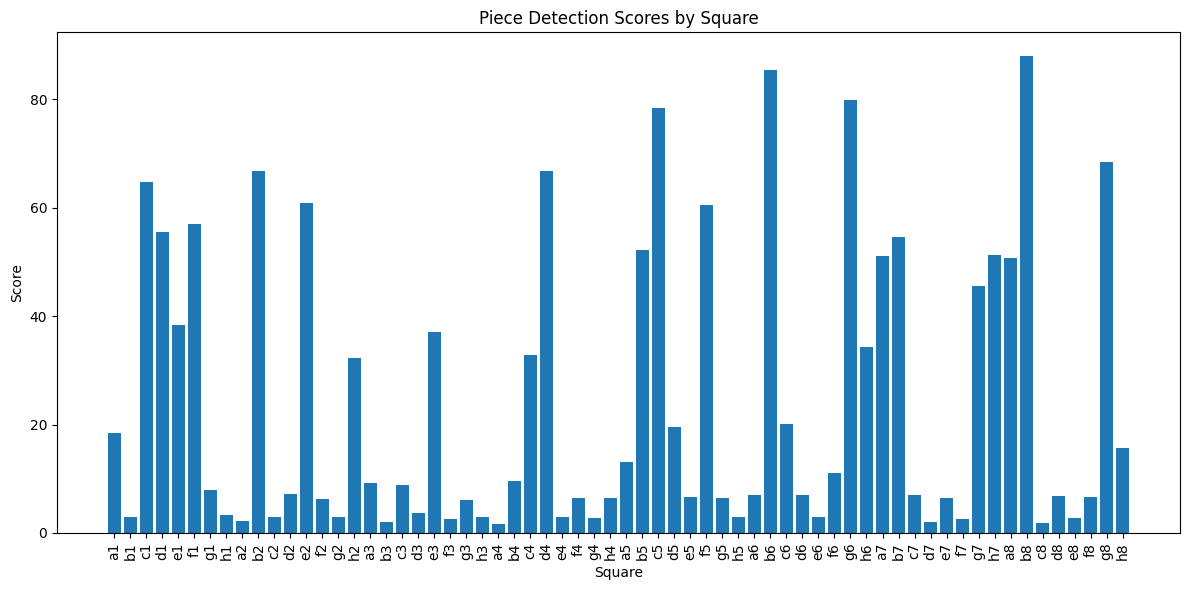

In [15]:
# Fixed improved chess piece detection
# Let's remove the Otsu thresholding that was causing the error
# and implement a simpler but reliable thresholding method

def advanced_piece_detection(image, squares_data):
    """
    Advanced chess piece detection with improved feature extraction
    and refined thresholds, with fixes for the errors
    """
    # Create a copy of the image
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    visualization = image.copy()
    
    # Extract and analyze features for all squares
    all_square_features = []
    
    # For visualization of decision process
    feature_values = []
    
    for square in squares_data:
        center = square["original_center"]
        
        # Use a percentage of the square size instead of fixed size
        # Estimate square size from the data
        roi_size = 30  # Start with a smaller ROI to avoid board border
        
        x1 = max(0, center[0] - roi_size)
        y1 = max(0, center[1] - roi_size)
        x2 = min(image.shape[1], center[0] + roi_size)
        y2 = min(image.shape[0], center[1] + roi_size)
        
        # Extract the ROI from both grayscale and color images
        roi_gray = gray_image[y1:y2, x1:x2]
        roi_color = image[y1:y2, x1:x2]
        
        if roi_gray.size == 0 or roi_color.size == 0:
            # Skip empty ROIs
            all_square_features.append({
                "square": square,
                "score": 0,
                "mean_intensity": 0,
                "bbox": (x1, y1, x2-x1, y2-y1),
                "has_piece": False
            })
            continue
        
        # 1. Calculate basic features
        variance = np.var(roi_gray)
        std_dev = np.std(roi_gray)
        
        # 2. Edge and gradient features
        # Use Canny edge detection
        edges = cv2.Canny(roi_gray, 50, 150)
        edge_pixels = np.count_nonzero(edges)
        edge_density = edge_pixels / roi_gray.size
        
        # Sobel gradients
        sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)
        gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
        avg_gradient = np.mean(gradient_magnitude)
        
        # 3. Color features (simpler approach without GLCM)
        hsv_roi = cv2.cvtColor(roi_color, cv2.COLOR_RGB2HSV)
        saturation = np.mean(hsv_roi[:,:,1])
        value = np.mean(hsv_roi[:,:,2])
        
        # 4. Calculate mean intensity (for piece color determination)
        mean_intensity = np.mean(roi_gray)
        
        # 5. Shape features - using contours
        _, thresh = cv2.threshold(roi_gray, 127, 255, cv2.THRESH_BINARY)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Number of contours and largest contour area
        num_contours = len(contours)
        max_contour_area = 0
        if contours:
            max_contour_area = max(cv2.contourArea(cnt) for cnt in contours)
        
        # Combine features into a "piece likelihood score"
        # This is a weighted combination of features that indicate a piece is present
        piece_score = (
            0.3 * std_dev +                # Higher for pieces
            0.3 * edge_density * 1000 +    # Higher for pieces 
            0.3 * avg_gradient +           # Higher for pieces
            0.1 * max_contour_area / 100   # Higher for pieces (distinct shapes)
        )
        
        # Store features for analysis
        feature_values.append({
            "position": f"{square['file']}{square['rank']}",
            "std_dev": std_dev,
            "edge_density": edge_density,
            "avg_gradient": avg_gradient,
            "max_contour_area": max_contour_area,
            "piece_score": piece_score
        })
        
        # Store all features
        all_square_features.append({
            "square": square,
            "std_dev": std_dev,
            "edge_density": edge_density,
            "avg_gradient": avg_gradient,
            "score": piece_score,
            "mean_intensity": mean_intensity,
            "bbox": (x1, y1, x2-x1, y2-y1)
        })
    
    # Analyze the distribution of piece scores to determine threshold
    scores = [f["score"] for f in all_square_features]
    sorted_scores = sorted(scores)
    
    # We expect roughly 32 pieces on a chess board at the start of a game
    # But since this may be a game in progress, let's find a natural split point
    
    # Simple percentile-based approach instead of Otsu
    detection_threshold = 0
    
    if len(sorted_scores) > 0:
        # Try to find a natural gap in the middle of the distribution
        if len(sorted_scores) > 10:
            # Look for a significant gap in the middle part of distribution
            middle_start = len(sorted_scores) // 3
            middle_end = 2 * len(sorted_scores) // 3
            
            max_gap = 0
            gap_threshold = sorted_scores[len(sorted_scores) // 2]  # Start with median
            
            for i in range(middle_start, middle_end):
                gap = sorted_scores[i+1] - sorted_scores[i]
                if gap > max_gap:
                    max_gap = gap
                    gap_threshold = sorted_scores[i] + gap/2
            
            # Only use gap if it's significant
            if max_gap > (sorted_scores[-1] - sorted_scores[0]) / 20:
                detection_threshold = gap_threshold
            else:
                # Otherwise use 40th percentile - this assumes about 60% of squares have pieces
                idx = int(len(sorted_scores) * 0.4)
                detection_threshold = sorted_scores[idx]
        else:
            # For small number of squares, use median
            detection_threshold = sorted_scores[len(sorted_scores) // 2]
    
    # Print the threshold for debugging
    print(f"Piece detection threshold: {detection_threshold}")
    
    # Apply threshold to detect pieces
    white_pieces = []
    black_pieces = []
    board_matrix = [[0 for _ in range(8)] for _ in range(8)]
    
    for features in all_square_features:
        square = features["square"]
        score = features["score"]
        mean_intensity = features["mean_intensity"]
        bbox = features["bbox"]
        
        # Get chess coordinates
        file = square["file"]
        rank = square["rank"]
        file_idx = ord(file) - ord('a')
        rank_idx = rank - 1
        
        center = square["original_center"]
        
        # Determine if this square contains a piece
        has_piece = score > detection_threshold
        features["has_piece"] = has_piece
        
        # Set color based on intensity and board position
        # Chess board alternates colors, so we can use this to improve color detection
        is_dark_square = (file_idx + rank_idx) % 2 == 1
        
        # Adjust intensity threshold based on square color
        intensity_threshold = 100 if is_dark_square else 130
        
        piece_color = "white" if mean_intensity > intensity_threshold else "black"
        
        # Update visualization and data structures
        if has_piece:
            # Mark on the visualization
            color = (0, 255, 0) if piece_color == "white" else (0, 0, 255)
            x1, y1, w, h = bbox
            cv2.rectangle(visualization, (x1, y1), (x1+w, y1+h), color, 2)
            
            label = "W" if piece_color == "white" else "B"
            cv2.putText(visualization, f"{label}", (center[0], center[1] - 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            
            cv2.putText(visualization, f"{file}{rank}", (center[0] - 15, center[1] + 15),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
            
            # Update the board matrix
            board_matrix[7 - rank_idx][file_idx] = 1
            
            # Add to the appropriate list
            piece_data = {
                "color": piece_color,
                "position": f"{file}{rank}",
                "center": center,
                "bbox": bbox,
                "file_idx": file_idx,
                "rank_idx": rank_idx,
                "score": score
            }
            
            if piece_color == "white":
                white_pieces.append(piece_data)
            else:
                black_pieces.append(piece_data)
    
    # Create the result structure
    result = {
        "white_pieces_count": len(white_pieces),
        "black_pieces_count": len(black_pieces),
        "total_pieces_count": len(white_pieces) + len(black_pieces),
        "white_pieces": white_pieces,
        "black_pieces": black_pieces,
        "board_matrix": board_matrix,
        "feature_values": feature_values
    }
    
    return result, visualization

# Apply the fixed detection
advanced_detection_result, advanced_visualization = advanced_piece_detection(rgb_image, squares_data)

# Display the improved detection
plt.figure(figsize=(12, 10))
plt.imshow(advanced_visualization)
plt.title("Fixed Improved Piece Detection")
plt.show()

# Print statistics
print(f"Total pieces detected: {advanced_detection_result['total_pieces_count']}")
print(f"White pieces: {advanced_detection_result['white_pieces_count']}")
print(f"Black pieces: {advanced_detection_result['black_pieces_count']}")

# Display the board matrix
print("\nBoard Matrix (1 for piece, 0 for empty):")
for row in advanced_detection_result['board_matrix']:
    print(row)

# Visualize feature distributions to help with debugging
# Plot the distribution of piece scores
feature_values = advanced_detection_result['feature_values']
scores = [f["piece_score"] for f in feature_values]
positions = [f["position"] for f in feature_values]

plt.figure(figsize=(12, 6))
plt.bar(positions, scores)
plt.title("Piece Detection Scores by Square")
plt.xlabel("Square")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# PESSOAL, AQUI AINDA NAO ESTA A DETECTAR PERFEITO, MAS ESTA ENCAMINHANDO... SO QUE PARA OUTRAS IMAGENS ESTA FODIDO, ENTAO QUEM FOR MEXER NESTE CODIGO TENTE COM O CLAUDIN FAZER FICAR MELHOR A GENERALIZAR PLSS